In [22]:

# Imports
import pandas as pd
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report

# Leitura Dataset
students_df = pd.read_csv("predict_students_dropout_and_academic_success.csv", sep = ';')
students_df.columns = students_df.columns.str.strip()


In [23]:

# Separação coluna target
x = students_df.drop('Target', axis=1)
y = students_df['Target']


In [24]:

# Split de 70% treino e 30% teste 
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)


In [25]:

# Normalização dos dados
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [26]:

# Verificação do desbalanceamento do atributo alvo
y_train.value_counts()


Target
Graduate    1567
Dropout      980
Enrolled     549
Name: count, dtype: int64

In [27]:

# Método de SMOTE
smote = SMOTE(random_state=42)
x_res, y_res = smote.fit_resample(x_train_scaled, y_train)

# Método de Redução de dados
rus = RandomUnderSampler(random_state=42)
x_under, y_under = rus.fit_resample(x_train_scaled, y_train)

# Validação cruzada fixada em 5 splits
cv_fixed = KFold(n_splits=5, shuffle=True, random_state=42)


In [28]:

# Verificação do resultado do SMOTE
y_res.value_counts()


Target
Dropout     1567
Graduate    1567
Enrolled    1567
Name: count, dtype: int64

In [29]:

# Verificação do resultado da Redução de Dados
y_under.value_counts()


Target
Dropout     549
Enrolled    549
Graduate    549
Name: count, dtype: int64

In [30]:

# Função para impressão da Matriz de confusão para métodos classificadores
def conf_matrix(MLmodel, x_teste, y_teste, modelName):
    y_pred = MLmodel.predict(x_teste)

    cm = confusion_matrix(y_teste, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=MLmodel.classes_)
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix: {modelName}')
    plt.show()

    print(f"        Classification Report: {MLmodel}")
    print(classification_report(y_teste, y_pred))
    

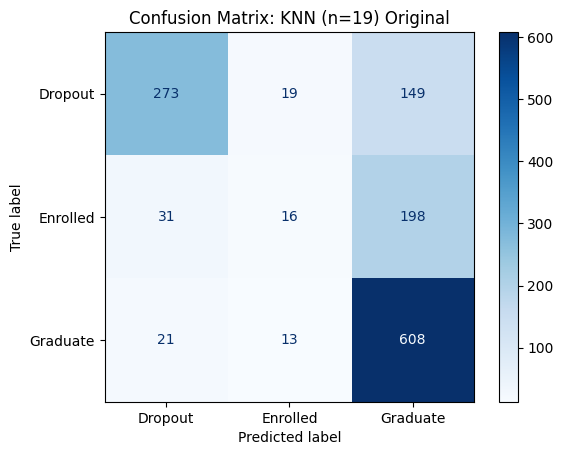

        Classification Report: KNeighborsClassifier(n_neighbors=19)
              precision    recall  f1-score   support

     Dropout       0.84      0.62      0.71       441
    Enrolled       0.33      0.07      0.11       245
    Graduate       0.64      0.95      0.76       642

    accuracy                           0.68      1328
   macro avg       0.60      0.54      0.53      1328
weighted avg       0.65      0.68      0.62      1328



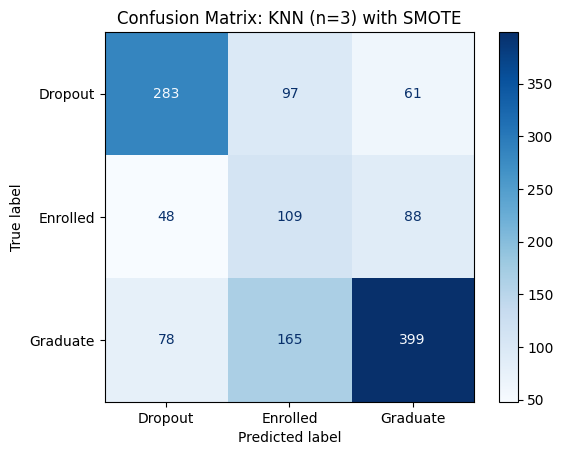

        Classification Report: KNeighborsClassifier(n_neighbors=3)
              precision    recall  f1-score   support

     Dropout       0.69      0.64      0.67       441
    Enrolled       0.29      0.44      0.35       245
    Graduate       0.73      0.62      0.67       642

    accuracy                           0.60      1328
   macro avg       0.57      0.57      0.56      1328
weighted avg       0.64      0.60      0.61      1328



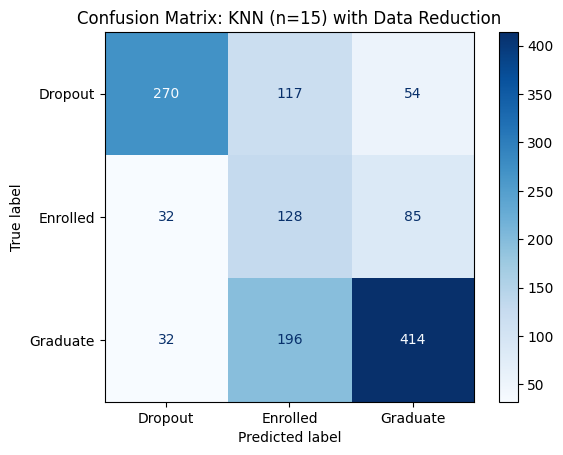

        Classification Report: KNeighborsClassifier(n_neighbors=15)
              precision    recall  f1-score   support

     Dropout       0.81      0.61      0.70       441
    Enrolled       0.29      0.52      0.37       245
    Graduate       0.75      0.64      0.69       642

    accuracy                           0.61      1328
   macro avg       0.62      0.59      0.59      1328
weighted avg       0.68      0.61      0.64      1328



In [31]:
# KNN com validação cruzada

# Parâmetros para teste 
# Todos são ímpares para que não haja empate nas distâncias do KNN 
knn_parameters = {'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17, 19, 21]}

# Teste do KNN com a base de dados original
grid_knn_original = GridSearchCV(KNeighborsClassifier(), knn_parameters, cv=5, scoring='accuracy')
grid_knn_original.fit(x_train_scaled, y_train)
best_knn_original = grid_knn_original.best_estimator_
conf_matrix(best_knn_original, x_test_scaled, y_test, modelName=f"KNN (n={grid_knn_original.best_params_['n_neighbors']}) Original")

# Teste do KNN com SMOTE
grid_knn_smote = GridSearchCV(KNeighborsClassifier(), knn_parameters, cv=5, scoring='accuracy')
grid_knn_smote.fit(x_res, y_res)
best_knn_smote = grid_knn_smote.best_estimator_
conf_matrix(best_knn_smote, x_test_scaled, y_test, modelName=f"KNN (n={grid_knn_smote.best_params_['n_neighbors']}) with SMOTE")

# Teste do KNN com Redução de Dados
grid_knn_reduzido = GridSearchCV(KNeighborsClassifier(), knn_parameters, cv=5, scoring='accuracy')
grid_knn_reduzido.fit(x_under, y_under)
best_knn_reduzido = grid_knn_reduzido.best_estimator_
conf_matrix(best_knn_reduzido, x_test_scaled, y_test, modelName=f"KNN (n={grid_knn_reduzido.best_params_['n_neighbors']}) with Data Reduction")


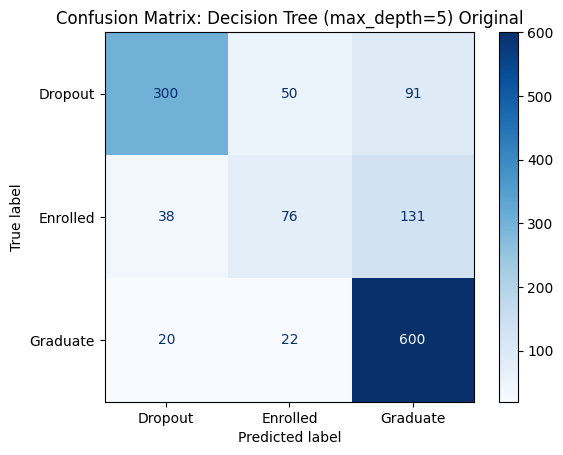

        Classification Report: DecisionTreeClassifier(max_depth=5)
              precision    recall  f1-score   support

     Dropout       0.84      0.68      0.75       441
    Enrolled       0.51      0.31      0.39       245
    Graduate       0.73      0.93      0.82       642

    accuracy                           0.73      1328
   macro avg       0.69      0.64      0.65      1328
weighted avg       0.73      0.73      0.72      1328



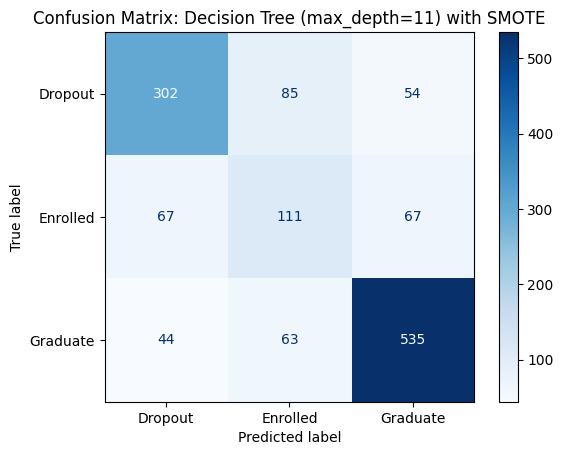

        Classification Report: DecisionTreeClassifier(max_depth=11)
              precision    recall  f1-score   support

     Dropout       0.73      0.68      0.71       441
    Enrolled       0.43      0.45      0.44       245
    Graduate       0.82      0.83      0.82       642

    accuracy                           0.71      1328
   macro avg       0.66      0.66      0.66      1328
weighted avg       0.72      0.71      0.71      1328



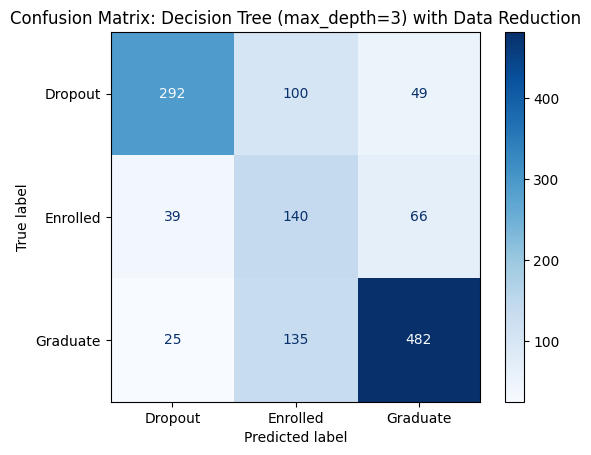

        Classification Report: DecisionTreeClassifier(max_depth=3)
              precision    recall  f1-score   support

     Dropout       0.82      0.66      0.73       441
    Enrolled       0.37      0.57      0.45       245
    Graduate       0.81      0.75      0.78       642

    accuracy                           0.69      1328
   macro avg       0.67      0.66      0.65      1328
weighted avg       0.73      0.69      0.70      1328



In [34]:
# Árvore de Decisão com validação cruzada

# Parâmetros para teste
# Todos são iguais aos do KNN para comparação 
dt_parameters = {'max_depth': [3, 5, 7, 9, 11, 13, 15, 17, 19, 21]}

# Teste da Árvore de Decisão com a base de dados original
grid_dt_original = GridSearchCV(DecisionTreeClassifier(), dt_parameters, cv=5, scoring='accuracy')
grid_dt_original.fit(x_train_scaled, y_train)
best_dt_original = grid_dt_original.best_estimator_
conf_matrix(best_dt_original, x_test_scaled, y_test, modelName=f"Decision Tree (max_depth={grid_dt_original.best_params_['max_depth']}) Original")

# Teste da Árvore de Decisão com SMOTE
grid_dt_smote = GridSearchCV(DecisionTreeClassifier(), dt_parameters, cv=5, scoring='accuracy')
grid_dt_smote.fit(x_res, y_res)
best_dt_smote = grid_dt_smote.best_estimator_
conf_matrix(best_dt_smote, x_test_scaled, y_test, modelName=f"Decision Tree (max_depth={grid_dt_smote.best_params_['max_depth']}) with SMOTE")

# Teste da Árvore de Decisão com Redução de Dados 
grid_dt_reduzido = GridSearchCV(DecisionTreeClassifier(), dt_parameters, cv=5, scoring='accuracy')
grid_dt_reduzido.fit(x_under, y_under)
best_dt_reduzido = grid_dt_reduzido.best_estimator_
conf_matrix(best_dt_reduzido, x_test_scaled, y_test, modelName=f"Decision Tree (max_depth={grid_dt_reduzido.best_params_['max_depth']}) with Data Reduction")


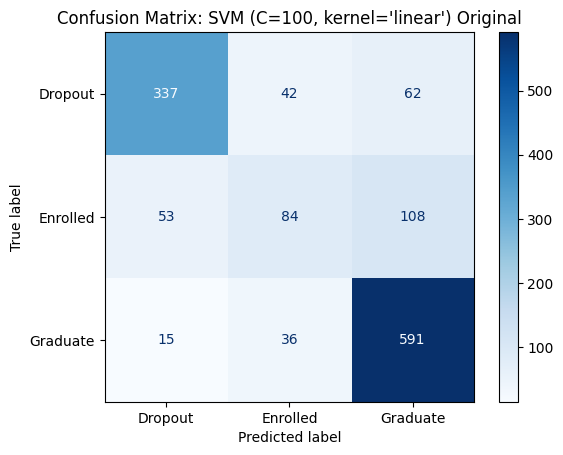

        Classification Report: SVC(C=100, kernel='linear', random_state=42)
              precision    recall  f1-score   support

     Dropout       0.83      0.76      0.80       441
    Enrolled       0.52      0.34      0.41       245
    Graduate       0.78      0.92      0.84       642

    accuracy                           0.76      1328
   macro avg       0.71      0.68      0.68      1328
weighted avg       0.75      0.76      0.75      1328



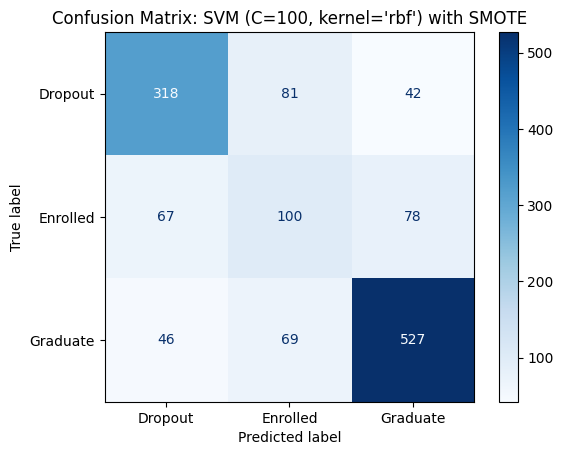

        Classification Report: SVC(C=100, random_state=42)
              precision    recall  f1-score   support

     Dropout       0.74      0.72      0.73       441
    Enrolled       0.40      0.41      0.40       245
    Graduate       0.81      0.82      0.82       642

    accuracy                           0.71      1328
   macro avg       0.65      0.65      0.65      1328
weighted avg       0.71      0.71      0.71      1328



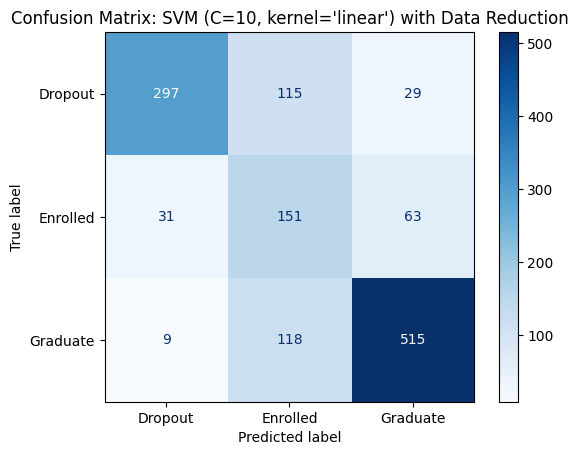

        Classification Report: SVC(C=10, kernel='linear', random_state=42)
              precision    recall  f1-score   support

     Dropout       0.88      0.67      0.76       441
    Enrolled       0.39      0.62      0.48       245
    Graduate       0.85      0.80      0.82       642

    accuracy                           0.73      1328
   macro avg       0.71      0.70      0.69      1328
weighted avg       0.78      0.73      0.74      1328



In [35]:
# SVM com validação cruzada

# Parâmetros para teste
# Parâmetros diferentes dos anteriores porque exigem quantidade de erro permitido e tipo de função
svm_parameters = {
    'C': [1, 10, 100],
    'kernel': ['linear', 'rbf']
}

# Teste do SVM com a base de dados original
grid_svm_original = GridSearchCV(SVC(random_state=42), svm_parameters, cv=cv_fixed, scoring='accuracy')
grid_svm_original.fit(x_train_scaled, y_train)
best_svm_original = grid_svm_original.best_estimator_
conf_matrix(best_svm_original, x_test_scaled, y_test, modelName=f"SVM (C={grid_svm_original.best_params_['C']}, kernel='{grid_svm_original.best_params_['kernel']}') Original")

# Teste do SVM com SMOTE
grid_svm_smote = GridSearchCV(SVC(random_state=42), svm_parameters, cv=cv_fixed, scoring='accuracy')
grid_svm_smote.fit(x_res, y_res)
best_svm_smote = grid_svm_smote.best_estimator_
conf_matrix(best_svm_smote, x_test_scaled, y_test, modelName=f"SVM (C={grid_svm_smote.best_params_['C']}, kernel='{grid_svm_smote.best_params_['kernel']}') with SMOTE")

# Teste do SVM com Redução de Dados
grid_svm_reduzido = GridSearchCV(SVC(random_state=42), svm_parameters, cv=cv_fixed, scoring='accuracy')
grid_svm_reduzido.fit(x_under, y_under)
best_svm_reduzido = grid_svm_reduzido.best_estimator_
conf_matrix(best_svm_reduzido, x_test_scaled, y_test, modelName=f"SVM (C={grid_svm_reduzido.best_params_['C']}, kernel='{grid_svm_reduzido.best_params_['kernel']}') with Data Reduction")


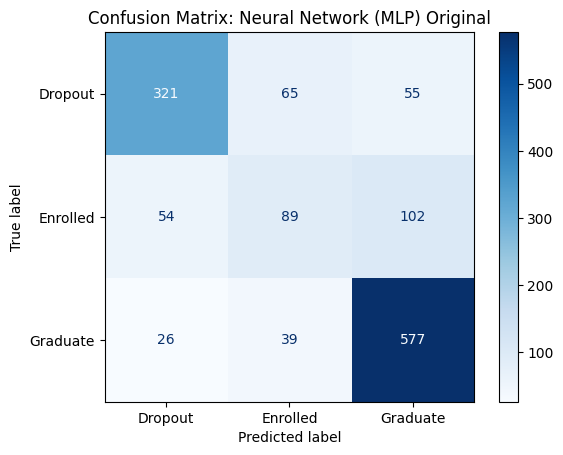

        Classification Report: MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=3000, random_state=42)
              precision    recall  f1-score   support

     Dropout       0.80      0.73      0.76       441
    Enrolled       0.46      0.36      0.41       245
    Graduate       0.79      0.90      0.84       642

    accuracy                           0.74      1328
   macro avg       0.68      0.66      0.67      1328
weighted avg       0.73      0.74      0.73      1328



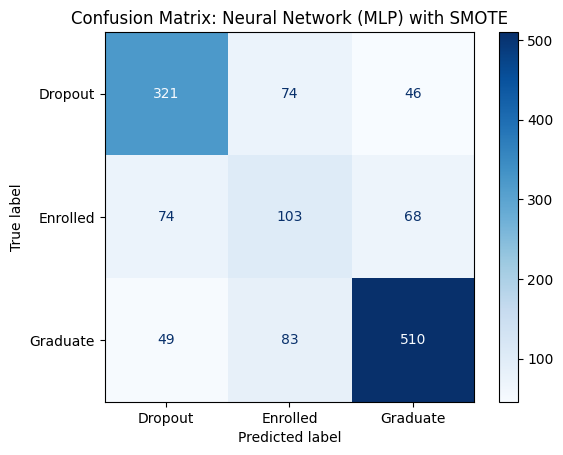

        Classification Report: MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=3000, random_state=42)
              precision    recall  f1-score   support

     Dropout       0.72      0.73      0.73       441
    Enrolled       0.40      0.42      0.41       245
    Graduate       0.82      0.79      0.81       642

    accuracy                           0.70      1328
   macro avg       0.65      0.65      0.65      1328
weighted avg       0.71      0.70      0.71      1328



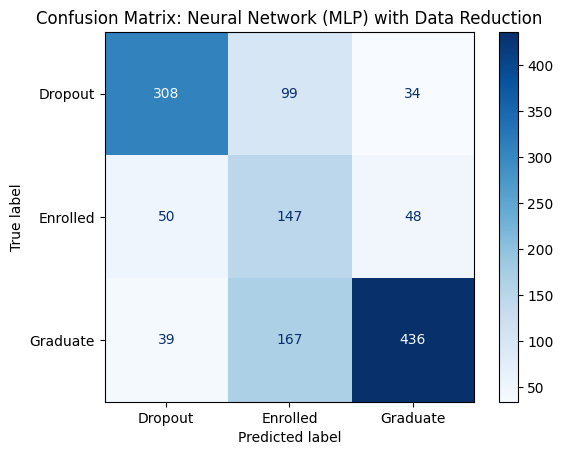

        Classification Report: MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=3000, random_state=42)
              precision    recall  f1-score   support

     Dropout       0.78      0.70      0.74       441
    Enrolled       0.36      0.60      0.45       245
    Graduate       0.84      0.68      0.75       642

    accuracy                           0.67      1328
   macro avg       0.66      0.66      0.64      1328
weighted avg       0.73      0.67      0.69      1328



In [36]:
# Rede Neural

# Parâmetros para teste de validação cruzada
mlp_parameters = {
    'hidden_layer_sizes': [(64, 32)],
    'max_iter': [3000] 
}

# Teste da Rede Neural com a base de dados original
grid_mlp_original = GridSearchCV(MLPClassifier(random_state=42), mlp_parameters, cv=cv_fixed, scoring='accuracy')
grid_mlp_original.fit(x_train_scaled, y_train)
best_mlp_original = grid_mlp_original.best_estimator_
conf_matrix(best_mlp_original, x_test_scaled, y_test, modelName="Neural Network (MLP) Original")

# Teste da Rede Neural com SMOTE
grid_mlp_smote = GridSearchCV(MLPClassifier(random_state=42), mlp_parameters, cv=cv_fixed, scoring='accuracy')
grid_mlp_smote.fit(x_res, y_res)
best_mlp_smote = grid_mlp_smote.best_estimator_
conf_matrix(best_mlp_smote, x_test_scaled, y_test, modelName="Neural Network (MLP) with SMOTE")

# Teste da Rede Neural com Redução de Dados
grid_mlp_reduzido = GridSearchCV(MLPClassifier(random_state=42), mlp_parameters, cv=cv_fixed, scoring='accuracy')
grid_mlp_reduzido.fit(x_under, y_under)
best_mlp_reduzido = grid_mlp_reduzido.best_estimator_
conf_matrix(best_mlp_reduzido, x_test_scaled, y_test, modelName="Neural Network (MLP) with Data Reduction")
